<a href="https://colab.research.google.com/github/thahira-banu25/EDA-PlayStore-Analysis/blob/main/EDA_PlayStore_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA & Data Preprocessing on Google App Store Rating Dataset.

> Add blockquote



# **1. Import required libraries and read the dataset.**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as pylot
import seaborn as sns

In [ ]:
df=pd.read_csv('/Apps_data+(1).csv')
df

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up
...,...,...,...,...,...,...,...,...,...,...,...,...,...
10836,Sya9a Maroc - FR,FAMILY,4.5,38,53M,"5,000+",Free,0,Everyone,Education,"July 25, 2017",1.48,4.1 and up
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,4,3.6M,100+,Free,0,Everyone,Education,"July 6, 2018",1.0,4.1 and up
10838,Parkinson Exercices FR,MEDICAL,NaN,3,9.5M,"1,000+",Free,0,Everyone,Medical,"January 20, 2017",1.0,2.2 and up
10839,The SCP Foundation DB fr nn5n,BOOKS_AND_REFERENCE,4.5,114,Varies with device,"1,000+",Free,0,Mature 17+,Books & Reference,"January 19, 2015",Varies with device,Varies with device


#**2. Check the first few samples, shape, info of the data and try to familiarize yourself with different features.**

In [ ]:
df.shape

(10841, 13)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  object 
 1   Category        10841 non-null  object 
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  object 
 4   Size            10841 non-null  object 
 5   Installs        10841 non-null  object 
 6   Type            10840 non-null  object 
 7   Price           10841 non-null  object 
 8   Content Rating  10840 non-null  object 
 9   Genres          10841 non-null  object 
 10  Last Updated    10841 non-null  object 
 11  Current Ver     10833 non-null  object 
 12  Android Ver     10838 non-null  object 
dtypes: float64(1), object(12)
memory usage: 1.1+ MB


In [ ]:
df.sample()

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
7821,CS Guns Shoot,FAMILY,3.7,433,Varies with device,"50,000+",Free,0,Teen,Entertainment,"August 1, 2013",1.5,2.2 and up


In [ ]:
df.dtypes

,0
App,object
Category,object
Rating,float64
Reviews,object
Size,object
Installs,object
Type,object
Price,object
Content Rating,object
Genres,object


#**3. Check summary statistics of the dataset. List out the columns that need to be worked upon for model.**

In [ ]:
df.describe()

,Rating
count,9367.000000
mean,4.193338
std,0.537431
min,1.000000
25%,4.000000
50%,4.300000
75%,4.500000
max,19.000000


In [ ]:
df.describe(include='all')

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
count,10841,10841,9367.000000,10841,10841,10841,10840,10841,10840,10841,10841,10833,10838
unique,9660,34,NaN,6002,462,22,3,93,6,120,1378,2832,33
top,ROBLOX,FAMILY,NaN,0,Varies with device,"1,000,000+",Free,0,Everyone,Tools,"August 3, 2018",Varies with device,4.1 and up
freq,9,1972,NaN,596,1695,1579,10039,10040,8714,842,326,1459,2451
mean,NaN,NaN,4.193338,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,0.537431,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,4.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,4.300000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,4.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# **4. Check if there are any duplicate records in the dataset? if any drop them.**

In [ ]:
df.duplicated().sum()

np.int64(483)

In [ ]:
df.drop_duplicates(inplace =True)

In [ ]:
df.duplicated().sum()

np.int64(0)

# **5. Check the unique categories of the column 'Category', Is there any invalid category? If yes, drop them.**

In [ ]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION',
       '1.9'], dtype=object)

In [ ]:
df = df.drop(df[df['Category'] == '1.9'].index)

In [ ]:
df['Category'].unique()

array(['ART_AND_DESIGN', 'AUTO_AND_VEHICLES', 'BEAUTY',
       'BOOKS_AND_REFERENCE', 'BUSINESS', 'COMICS', 'COMMUNICATION',
       'DATING', 'EDUCATION', 'ENTERTAINMENT', 'EVENTS', 'FINANCE',
       'FOOD_AND_DRINK', 'HEALTH_AND_FITNESS', 'HOUSE_AND_HOME',
       'LIBRARIES_AND_DEMO', 'LIFESTYLE', 'GAME', 'FAMILY', 'MEDICAL',
       'SOCIAL', 'SHOPPING', 'PHOTOGRAPHY', 'SPORTS', 'TRAVEL_AND_LOCAL',
       'TOOLS', 'PERSONALIZATION', 'PRODUCTIVITY', 'PARENTING', 'WEATHER',
       'VIDEO_PLAYERS', 'NEWS_AND_MAGAZINES', 'MAPS_AND_NAVIGATION'],
      dtype=object)

# **6. Check if there are missing values present in the column Rating, If any? drop them and and create a new column as 'Rating_category' by converting ratings to high and low categories(>3.5 is high rest low)**

In [ ]:
df['Rating'].isnull().sum()

np.int64(1474)

In [ ]:
df.dropna(subset='Rating',inplace=True)


In [ ]:
df[['Rating']]

,Rating
0,4.1
1,3.9
2,4.7
3,4.5
4,4.3
...,...
10834,4.0
10836,4.5
10837,5.0
10839,4.5


In [ ]:
# Create new column Rating_category
df['Rating_category'] = df['Rating'].apply(
    lambda x: 'High' if x > 3.5 else 'Low'
)

In [ ]:
df['Rating_category']

,Rating_category
0,High
1,High
2,High
3,High
4,High
...,...
10834,High
10836,High
10837,High
10839,High


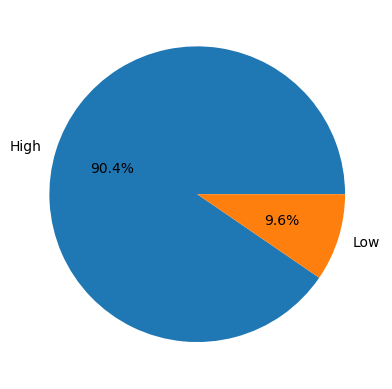

In [ ]:
pylot.pie(df.groupby(['Rating_category'])['Rating_category'].count(),autopct='%1.1f%%',labels=df.groupby(['Rating_category'])['Rating_category'].count().index)
pylot.show()

# **8. Convert the column "Reviews'' to numeric data type and check the presence of outliers in the column and handle the outliers using a transformation approach (Hint: Use log transformation)**

In [ ]:



df['Reviews']=pd.to_numeric(df['Reviews'],errors='coerce')


{'whiskers': [<matplotlib.lines.Line2D at 0x7e0fe9086210>,
 'caps': [<matplotlib.lines.Line2D at 0x7e0fe90869f0>,
 'boxes': [<matplotlib.lines.Line2D at 0x7e0fe9085e80>],
 'medians': [<matplotlib.lines.Line2D at 0x7e0fe9087020>],
 'fliers': [<matplotlib.lines.Line2D at 0x7e0fe90872f0>],
 'means': []}

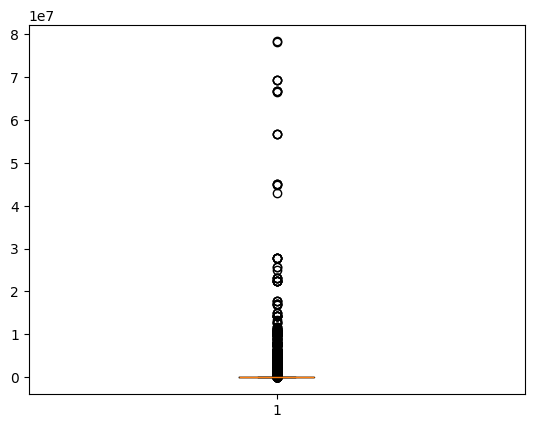

In [ ]:
pylot.boxplot(df['Reviews'].dropna())

In [ ]:
pylot.show()

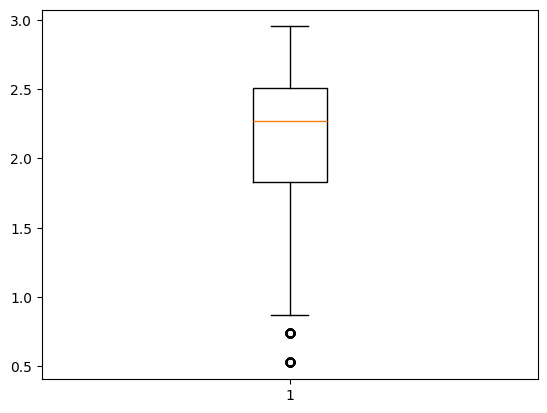

In [ ]:
df['Reviews']=np.log1p(df['Reviews'])
pylot.boxplot(df['Reviews'].dropna())
pylot.show()

# **9. The column 'Size' contains alphanumeric values, treat the non numeric data and convert the column into suitable data type. (hint: Replace M with 1 million and K with 1 thousand, and drop the entries where size='Varies with device')
**

In [ ]:
df['Size']=df['Size'].str.replace('M','*10**6').str.replace('k','*1000')
df['Size']




,Size
0,19*10**6
1,14*10**6
2,8.7*10**6
3,25*10**6
4,2.8*10**6
...,...
10834,2.6*10**6
10836,53*10**6
10837,3.6*10**6
10839,Varies with device


In [ ]:
df=df.drop(df[df['Size']=='Varies with device'].index)
df


,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver,Rating_category
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,1.804211,19000000.0,"10,000+",Free,0.0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up,High
1,Coloring book moana,ART_AND_DESIGN,3.9,2.063723,14000000.0,"500,000+",Free,0.0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up,High
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,2.516043,8700000.0,"5,000,000+",Free,0.0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up,High
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,2.586364,25000000.0,"50,000,000+",Free,0.0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up,High
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,2.063723,2800000.0,"100,000+",Free,0.0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10833,Chemin (fr),BOOKS_AND_REFERENCE,4.8,1.570003,619000.0,"1,000+",Free,0.0,Everyone,Books & Reference,"March 23, 2014",0.8,2.2 and up,High
10834,FR Calculator,FAMILY,4.0,1.124748,2600000.0,500+,Free,0.0,Everyone,Education,"June 18, 2017",1.0.0,4.1 and up,High
10836,Sya9a Maroc - FR,FAMILY,4.5,1.539779,53000000.0,"5,000+",Free,0.0,Everyone,Education,"July 25, 2017",1.48,4.1 and up,High
10837,Fr. Mike Schmitz Audio Teachings,FAMILY,5.0,0.959135,3600000.0,100+,Free,0.0,Everyone,Education,"July 6, 2018",1.0,4.1 and up,High


In [ ]:
df['Size']=df['Size'].map(eval).astype(float)

TypeError: eval() arg 1 must be a string, bytes or code object

In [ ]:
df['Size']



,Size
0,19000000.0
1,14000000.0
2,8700000.0
3,25000000.0
4,2800000.0
...,...
10833,619000.0
10834,2600000.0
10836,53000000.0
10837,3600000.0


TypeError: eval() arg 1 must be a string, bytes or code object

In [ ]:
print(df['Size'].head(10))
print(df['Size'].apply(type).value_counts())

0    19000000.0
1    14000000.0
2     8700000.0
3    25000000.0
4     2800000.0
5     5600000.0
6    19000000.0
7    29000000.0
8    33000000.0
9     3100000.0
Name: Size, dtype: float64
Size
<class 'float'>    7723
Name: count, dtype: int64


In [ ]:
df['Size'] = pd.to_numeric(df['Size'], errors='coerce')

# **10. Check the column 'Installs', treat the unwanted characters and convert the column into a suitable data type**

In [ ]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000+', '500,000,000+', '100+', '500+', '10+', '1,000,000,000+',
       '5+', '50+', '1+'], dtype=object)

In [ ]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000+', '500,000,000+', '100+', '500+', '10+', '1,000,000,000+',
       '5+', '50+', '1+'], dtype=object)

In [ ]:
df['Installs'].unique()

array(['10,000+', '500,000+', '5,000,000+', '50,000,000+', '100,000+',
       '50,000+', '1,000,000+', '10,000,000+', '5,000+', '100,000,000+',
       '1,000+', '500,000,000+', '100+', '500+', '10+', '1,000,000,000+',
       '5+', '50+', '1+'], dtype=object)

# **11.Check the column 'Price' , remove the unwanted characters and convert the column into a suitable data type.**

In [ ]:
df['Price'].unique()

array(['0', '$4.99', '$6.99', '$7.99', '$3.99', '$5.99', '$2.99', '$1.99',
       '$9.99', '$0.99', '$9.00', '$5.49', '$10.00', '$24.99', '$11.99',
       '$79.99', '$16.99', '$14.99', '$29.99', '$12.99', '$3.49',
       '$10.99', '$7.49', '$1.50', '$19.99', '$15.99', '$33.99', '$39.99',
       '$2.49', '$4.49', '$1.70', '$1.49', '$3.88', '$399.99', '$17.99',
       '$400.00', '$3.02', '$1.76', '$4.84', '$4.77', '$1.61', '$1.59',
       '$6.49', '$1.29', '$299.99', '$379.99', '$37.99', '$18.99',
       '$389.99', '$8.49', '$1.75', '$14.00', '$2.00', '$3.08', '$2.59',
       '$19.40', '$15.46', '$8.99', '$3.04', '$13.99', '$4.29', '$3.28',
       '$4.60', '$1.00', '$2.90', '$1.97', '$2.56', '$1.20'], dtype=object)

In [ ]:

df['Price']


,Price
0,0.0
1,0.0
2,0.0
3,0.0
4,0.0
...,...
10833,0.0
10834,0.0
10836,0.0
10837,0.0


In [ ]:
df['Price'].dtype

dtype('float64')

# **12. Drop the columns which you think redundant for the analysis.(suggestion: drop column 'rating', since we created a new feature from it (i.e. rating_category) and the columns 'App', 'Rating' ,'Genres','Last Updated', 'Current Ver','Android Ver' columns since which are redundant for our analysis)**

In [ ]:

df=df.drop(columns=['Current Ver','App','Rating','Genres','Last Updated','Android Ver','Size'])
df




KeyError: "['Current Ver', 'App', 'Rating', 'Genres', 'Last Updated', 'Android Ver', 'Size'] not found in axis"

In [ ]:
num_cols=df.select_dtypes(include=np.number).columns
num_cols


Index(['Reviews', 'Price'], dtype='object')

# **13. Encode the categorical columns.**

In [ ]:

catcols=df.select_dtypes(include='object').columns
catcols


Index(['Category', 'Installs', 'Type', 'Content Rating', 'Rating_category'], dtype='object')

In [ ]:


from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
for i in catcols:
    df[i]=le.fit_transform(df[i])

In [ ]:
df

,Category,Reviews,Installs,Type,Price,Content Rating,Rating_category
0,0,1.804211,5,0,0.0,1,0
1,0,2.063723,17,0,0.0,1,0
2,0,2.516043,12,0,0.0,1,0
3,0,2.586364,15,0,0.0,4,0
4,0,2.063723,8,0,0.0,1,0
...,...,...,...,...,...,...,...
10833,3,1.570003,1,0,0.0,1,0
10834,11,1.124748,16,0,0.0,1,0
10836,11,1.539779,11,0,0.0,1,0
10837,11,0.959135,7,0,0.0,1,0


# **14. Segregate the target and independent features (Hint: Use Rating_category as the target)**

In [ ]:

target=df[['Rating_category']]
target


,Rating_category
0,0
1,0
2,0
3,0
4,0
...,...
10833,0
10834,0
10836,0
10837,0


In [ ]:
independent_features=df.drop('Rating_category',axis=1)
independent_features


,Category,Reviews,Installs,Type,Price,Content Rating
0,0,1.804211,5,0,0.0,1
1,0,2.063723,17,0,0.0,1
2,0,2.516043,12,0,0.0,1
3,0,2.586364,15,0,0.0,4
4,0,2.063723,8,0,0.0,1
...,...,...,...,...,...,...
10833,3,1.570003,1,0,0.0,1
10834,11,1.124748,16,0,0.0,1
10836,11,1.539779,11,0,0.0,1
10837,11,0.959135,7,0,0.0,1


# **15. Split the dataset into train and test.**

In [ ]:

x=independent_features
y=target


In [ ]:

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)


# **16. Standardize the data, so that the values are within a particular range.**

In [ ]:
from sklearn.preprocessing import StandardScaler
standardization=StandardScaler()
df_std=standardization.fit_transform(df[num_cols])
df_std=pd.DataFrame(df_std)
df_std.columns=num_cols
df_std


,Reviews,Price
0,-0.495882,-0.064812
1,0.018416,-0.064812
2,0.914822,-0.064812
3,1.054182,-0.064812
4,0.018416,-0.064812
...,...,...
7718,-0.960033,-0.064812
7719,-1.842435,-0.064812
7720,-1.019930,-0.064812
7721,-2.170647,-0.064812


In [ ]:


df[['Reviews','Price']]=df_std[['Reviews','Price']]




In [ ]:
df

,Category,Reviews,Installs,Type,Price,Content Rating,Rating_category
0,0,-0.495882,5,0,-0.064812,1,0
1,0,0.018416,17,0,-0.064812,1,0
2,0,0.914822,12,0,-0.064812,1,0
3,0,1.054182,15,0,-0.064812,4,0
4,0,0.018416,8,0,-0.064812,1,0
...,...,...,...,...,...,...,...
10833,3,NaN,1,0,NaN,1,0
10834,11,NaN,16,0,NaN,1,0
10836,11,NaN,11,0,NaN,1,0
10837,11,NaN,7,0,NaN,1,0


# **PART II:Data Visualization on Honey Production dataset using seaborn and matplotlib libraries.**

# **1. Import required libraries and read the dataset**

In [ ]:
df1=pd.read_csv('honeyproduction.csv')
df1

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
0,AL,16000.0,71,1136000.0,159000.0,0.72,818000.0,1998
1,AZ,55000.0,60,3300000.0,1485000.0,0.64,2112000.0,1998
2,AR,53000.0,65,3445000.0,1688000.0,0.59,2033000.0,1998
3,CA,450000.0,83,37350000.0,12326000.0,0.62,23157000.0,1998
4,CO,27000.0,72,1944000.0,1594000.0,0.70,1361000.0,1998
...,...,...,...,...,...,...,...,...
621,VA,4000.0,41,164000.0,23000.0,3.77,618000.0,2012
622,WA,62000.0,41,2542000.0,1017000.0,2.38,6050000.0,2012
623,WV,6000.0,48,288000.0,95000.0,2.91,838000.0,2012
624,WI,60000.0,69,4140000.0,1863000.0,2.05,8487000.0,2012


# **2. Check the first few samples, shape, info of the data and try to familiarize yourself with different features.**

In [ ]:
df1.sample(5)

,state,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
584,WI,57000.0,63,3591000.0,1508000.0,1.89,6787000.0,2011
63,MO,24000.0,65,1560000.0,437000.0,0.68,1061000.0,1999
249,PA,27000.0,50,1350000.0,419000.0,1.44,1944000.0,2003
20,MO,23000.0,66,1518000.0,455000.0,0.76,1154000.0,1998
54,IA,40000.0,65,2600000.0,2028000.0,0.65,1690000.0,1999


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 626 entries, 0 to 625
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   state        626 non-null    object 
 1   numcol       626 non-null    float64
 2   yieldpercol  626 non-null    int64  
 3   totalprod    626 non-null    float64
 4   stocks       626 non-null    float64
 5   priceperlb   626 non-null    float64
 6   prodvalue    626 non-null    float64
 7   year         626 non-null    int64  
dtypes: float64(5), int64(2), object(1)
memory usage: 39.3+ KB


In [ ]:
df1.shape

(626, 8)

In [ ]:
df1.describe()

,numcol,yieldpercol,totalprod,stocks,priceperlb,prodvalue,year
count,626.000000,626.000000,6.260000e+02,6.260000e+02,626.000000,6.260000e+02,626.000000
mean,60284.345048,62.009585,4.169086e+06,1.318859e+06,1.409569,4.715741e+06,2004.864217
std,91077.087231,19.458754,6.883847e+06,2.272964e+06,0.638599,7.976110e+06,4.317306
min,2000.000000,19.000000,8.400000e+04,8.000000e+03,0.490000,1.620000e+05,1998.000000
25%,9000.000000,48.000000,4.750000e+05,1.430000e+05,0.932500,7.592500e+05,2001.000000
50%,26000.000000,60.000000,1.533000e+06,4.395000e+05,1.360000,1.841500e+06,2005.000000
75%,63750.000000,74.000000,4.175250e+06,1.489500e+06,1.680000,4.703250e+06,2009.000000
max,510000.000000,136.000000,4.641000e+07,1.380000e+07,4.150000,6.961500e+07,2012.000000


# **3. Display the percentage distribution of the data in each year using the pie chart.**

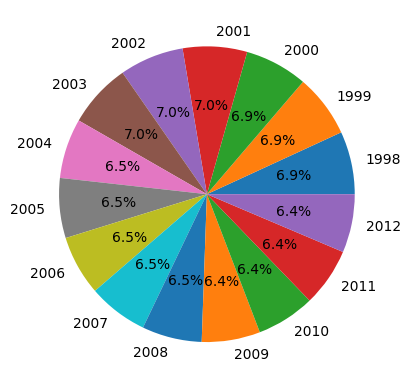

In [ ]:
pylot.pie(df1.groupby('year').size(),autopct='%1.1f%%',labels=df1.groupby('year').size().index)
pylot.show()


# **4. Plot and Understand the distribution of the variable "price per lb" using displot, and write your findings**

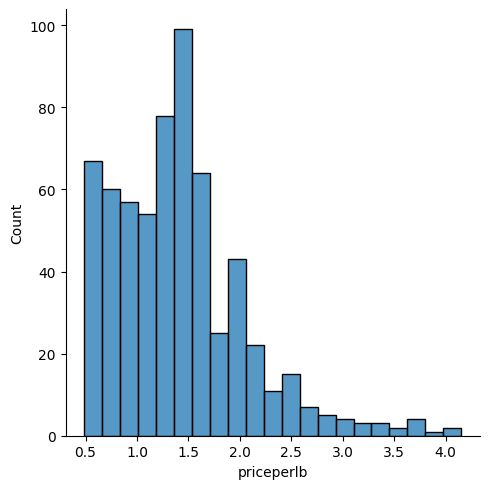

In [ ]:
sns.displot(df1['priceperlb'],kind='hist')
pylot.show()


# ** 5. Plot and understand the relationship between the variables 'numcol' and 'prodval' through scatterplot, and write your findings.**

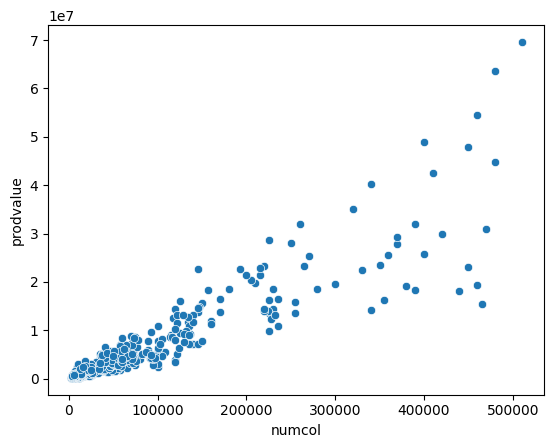

In [ ]:
sns.scatterplot(df1,x='numcol',y='prodvalue')
pylot.show()


# **6. Plot and understand the relationship between categorical variable 'year' and a numerical variable 'prodvalue' through boxplot, and write your findings.**

<Axes: xlabel='year', ylabel='prodvalue'>

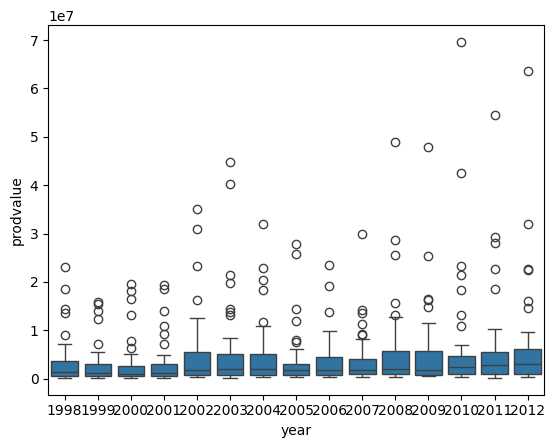

In [ ]:
sns.boxplot(df1,x='year',y='prodvalue')


# **7. Visualize and understand the relationship between the multiple pairs of variables throughout different years using pairplot and add your inferences. (use columns 'numcol', 'yield percol', 'total prod', 'prodvalue','year')**

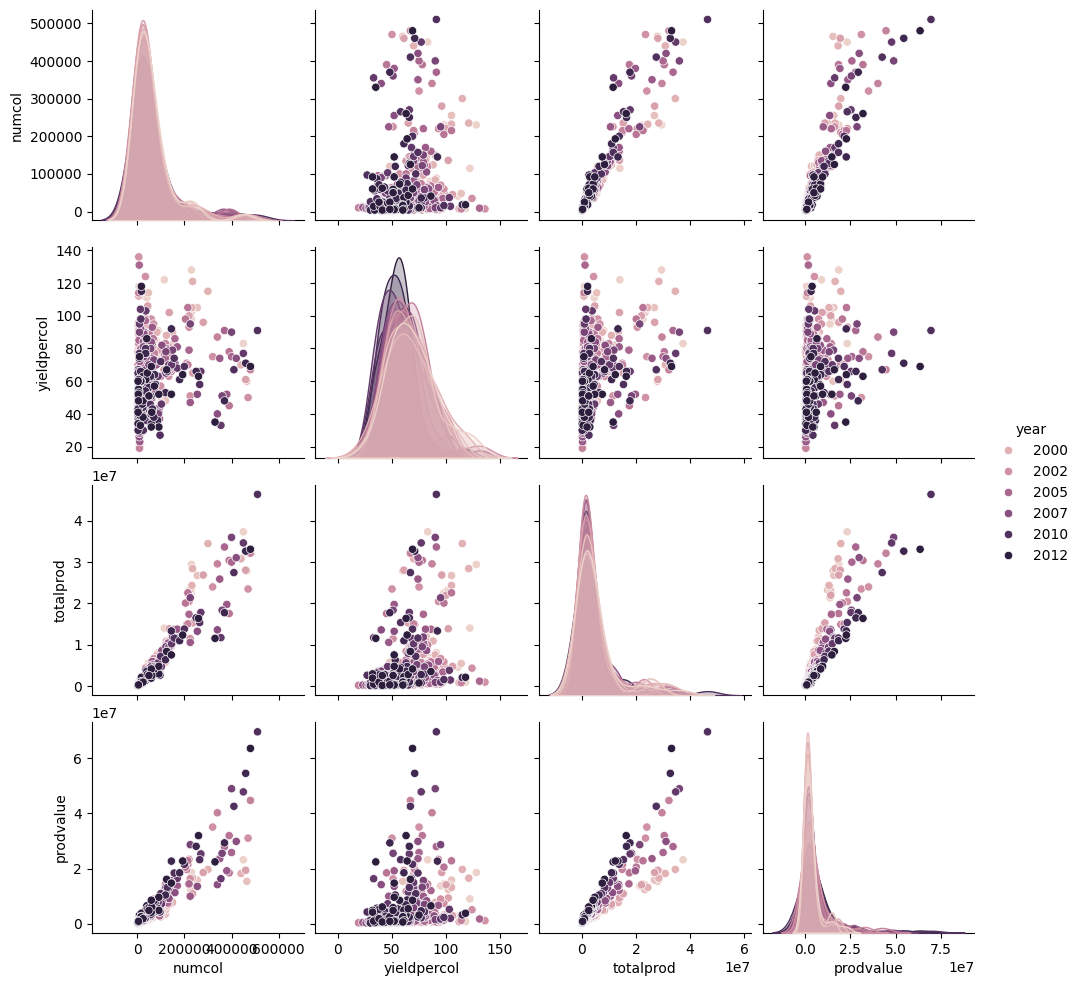

In [ ]:

sns.pairplot(df1[['numcol', 'yieldpercol', 'totalprod', 'prodvalue','year']],hue='year')



# **8. Display the correlation values using a plot and add your inferences. (use columns 'numcol', 'yield percol', 'total prod', 'stocks', 'price per lb', 'prodvalue')**

<Axes: >

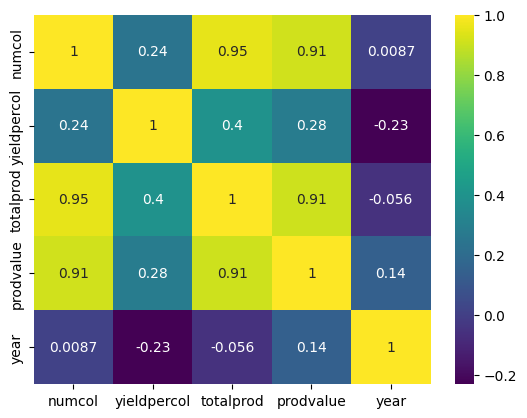

In [ ]:


sns.heatmap(df1[['numcol', 'yieldpercol', 'totalprod', 'prodvalue','year']].corr(),cmap='viridis',annot=True)
